# CatCLV - voting dataset

In [1]:
# disable warnings
from warnings import simplefilter, filterwarnings
simplefilter(action='ignore', category=FutureWarning)
filterwarnings("ignore")

## voting dataset

In [2]:
# poison dataset
from clustvartools.datasets import voting
data = voting.data
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 435 entries, 0 to 434
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   affiliation  435 non-null    str  
 1   budget       435 non-null    str  
 2   physician    435 non-null    str  
 3   salvador     435 non-null    str  
 4   nicaraguan   435 non-null    str  
 5   missile      435 non-null    str  
 6   education    435 non-null    str  
dtypes: str(7)
memory usage: 23.9 KB


## Instanciation and training

In [3]:
# instanciation
from clustvartools import CatCLV
clf = CatCLV(ncl=2,sup_var=0)

### `fit` function

In [4]:
# fit function
clf.fit(data)

,sup_var,0
,ncl,2
,row_w,None
,tol,1e-07
Name,Type,Value
call_,call,call(Xtot= ...affiliation'])
cluster_,cluster,cluster(summa... 4.593432e-96)
coef_,coef,coef(coef= ...NaN -0.280600)
quali_var_,quali_var,quali_var(clu...NaN -0.433189)
var_sup_,var_sup,var_sup(clust... 0.478433)


### `fit_transform` function

In [5]:
# fit_transform function - squared loadings
sqload = clf.fit_transform(data)
sqload

,1,2
budget,0.499226,0.791355
physician,0.575691,0.828474
salvador,0.887756,0.591985
nicaraguan,0.860118,0.566738
missile,0.827341,0.480459
education,0.437914,0.763481


### `transform` function

In [6]:
# transform function
sqload = clf.transform(voting.actif)
sqload

,1,2
budget,0.499226,0.791355
physician,0.575691,0.828474
salvador,0.887756,0.591985
nicaraguan,0.860118,0.566738
missile,0.827341,0.480459
education,0.437914,0.763481


### `fit_predict` function

In [7]:
# fit_predict function
prediction = clf.fit_predict(data)
prediction.to_frame()

,cluster
budget,2
physician,2
salvador,1
nicaraguan,1
missile,1
education,2


### `predict` function

In [8]:
# predict function
prediction = clf.predict(voting.actif)
prediction.to_frame()

,cluster
budget,2
physician,2
salvador,1
nicaraguan,1
missile,1
education,2


In [9]:
# attributes
from clustvartools import sprintf
sprintf(clf)


**Clustering of Variables - CatCLV**

*The results are available in the following objects:

name         description
-----------  -------------------------------------
.call_       summary called parameters
.cluster_    results for clusters
.coef_       Coefficients
.quali_var_  results for the categorical variables
.var_sup_    results for supplementary variables



## Cluster informations

In [10]:
# clusters informations
cluster = clf.cluster_
cluster._fields

('summary', 'princomps', 'cor', 'cortest')

### Cluster summary

In [11]:
# cluster summary
cluster_summary = clf.cluster_.summary
cluster_summary

,Cluster,Members,Variation Explained,Proportion Explained
0,1,3,2.575215,0.429203
1,2,3,2.383310,0.397218


### Inter-cluster correlations

In [12]:
# inter-cluster correlations
icor = cluster.cor
icor

,1,2
1,1.000000,0.795049
2,0.795049,1.000000


### Latent variables

In [13]:
# latent variables
princomps = cluster.princomps
princomps.head()

,1,2
0,-1.858722,-2.116108
1,-1.858722,-2.116108
2,-1.858722,1.366745
3,-1.237710,1.464050
4,-1.858722,1.043112


## Coefficients

In [14]:
# coefficients
coeffs = clf.coef_
coeffs._fields

('coef', 'coef_std')

### Coefficients of linear combinations

In [15]:
# coefficients of linear combinations
coef = coeffs.coef
coef

,1,2
const,3.330669e-16,5.551115e-16
budget_budget.n,NaN,-7.136051e-01
budget_budget.neither,NaN,1.737009e-01
budget_budget.y,NaN,4.747658e-01
physician_physician.n,NaN,4.923318e-01
physician_physician.neither,NaN,3.950269e-01
physician_physician.y,NaN,-7.115890e-01
salvador_salvador.n,6.022180e-01,NaN
salvador_salvador.neither,2.816341e-02,NaN
salvador_salvador.y,-5.928480e-01,NaN


### Standardized scoring coefficients

In [16]:
# standardized scoring coefficients
coef_std = coeffs.coef_std
coef_std

,1,2
budget_budget.n,NaN,-0.289815
budget_budget.neither,NaN,0.017892
budget_budget.y,NaN,0.234533
physician_physician.n,NaN,0.240310
physician_physician.neither,NaN,0.040690
physician_physician.y,NaN,-0.294023
salvador_salvador.n,0.259498,NaN
salvador_salvador.neither,0.003259,NaN
salvador_salvador.y,-0.257905,NaN
nicaraguan_nicaraguan.n,-0.268599,NaN


## Variables informations

In [17]:
# variables informations
var_ = clf.quali_var_
var_._fields

('cluster', 'sqload', 'member', 'sim', 'loadings')

### Variables loadings (=eigenvectors)

In [18]:
# variables loadings
var_.loadings

,1,2
budget_budget.n,NaN,-0.447416
budget_budget.neither,NaN,0.027622
budget_budget.y,NaN,0.362072
physician_physician.n,NaN,0.370990
physician_physician.neither,NaN,0.062817
physician_physician.y,NaN,-0.453912
salvador_salvador.n,0.416429,NaN
salvador_salvador.neither,0.005230,NaN
salvador_salvador.y,-0.413873,NaN
nicaraguan_nicaraguan.n,-0.431034,NaN


### Squared Loadings (=correlation ratio)

In [19]:
# squared loadings
var_.sqload

,1,2
budget,0.499226,0.791355
physician,0.575691,0.828474
salvador,0.887756,0.591985
nicaraguan,0.860118,0.566738
missile,0.827341,0.480459
education,0.437914,0.763481


### Cluster member

In [20]:
# cluster member
var_.member.sort_values(by=["Cluster","Variable"])

,Variable,Cluster,Own Cluster,Next Closest,1 - R**2 Ratio
4,missile,1,0.827341,0.480459,0.33233
3,nicaraguan,1,0.860118,0.566738,0.322857
2,salvador,1,0.887756,0.591985,0.275098
0,budget,2,0.791355,0.499226,0.416646
5,education,2,0.763481,0.437914,0.420787
1,physician,2,0.828474,0.575691,0.404247


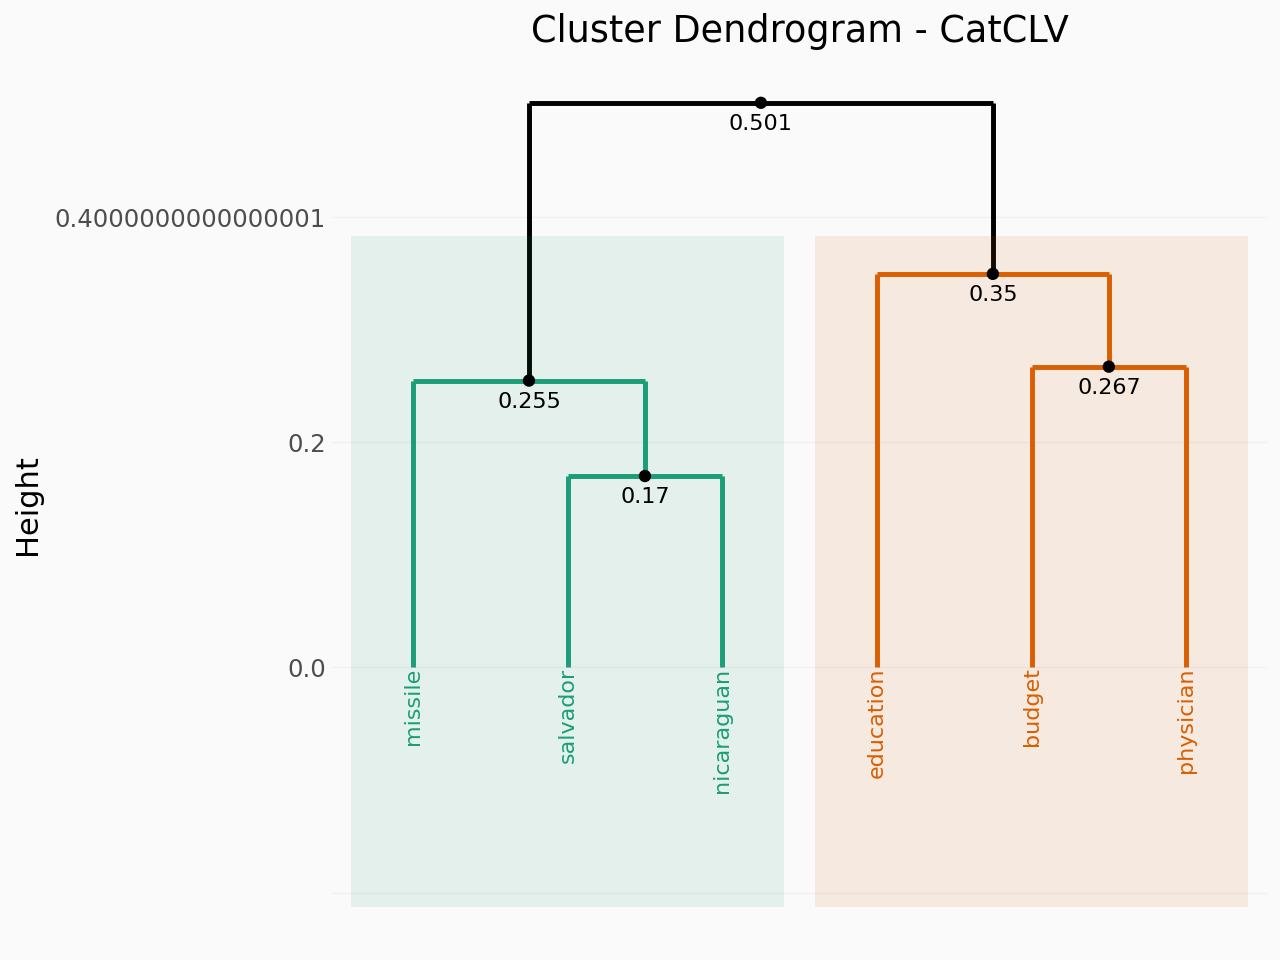

None


In [21]:
# dendrogram
from clustvartools import fviz_dend, fviz_height
p = fviz_dend(obj=clf,
              rect=True,
              rect_fill=True,
              color_labels_by_cluster=True,
              text_size=8,
              text_height=True,
              nudge_y=-0.01)
print(p.show())

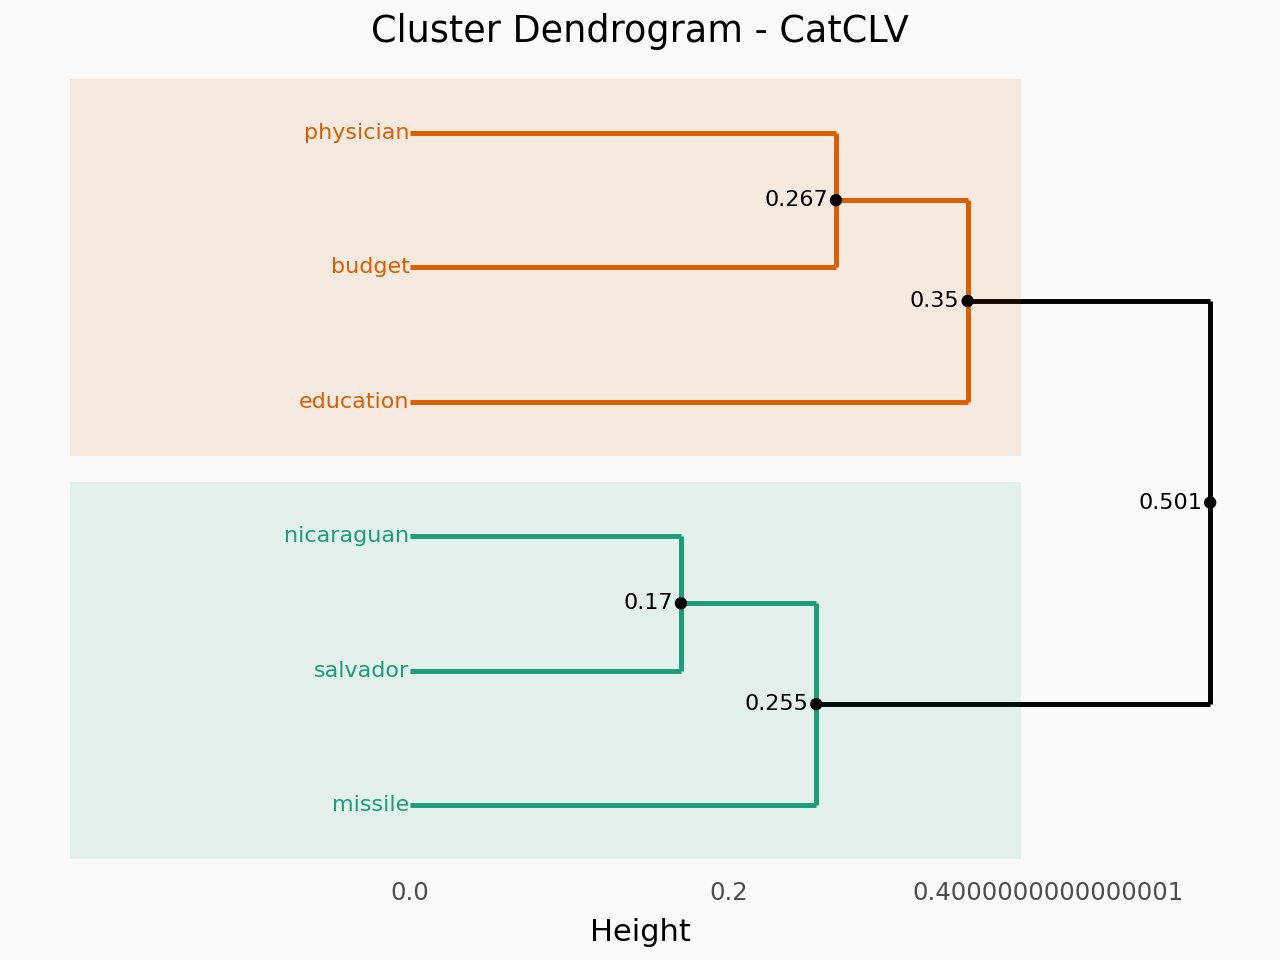

None


In [22]:
# horizon 
p = fviz_dend(obj=clf,
              horiz=True,
              rect=True,
              rect_fill=True,
              color_labels_by_cluster=True,
              text_size=8,
              text_height=True,
              nudge_x=-0.005)
print(p.show())

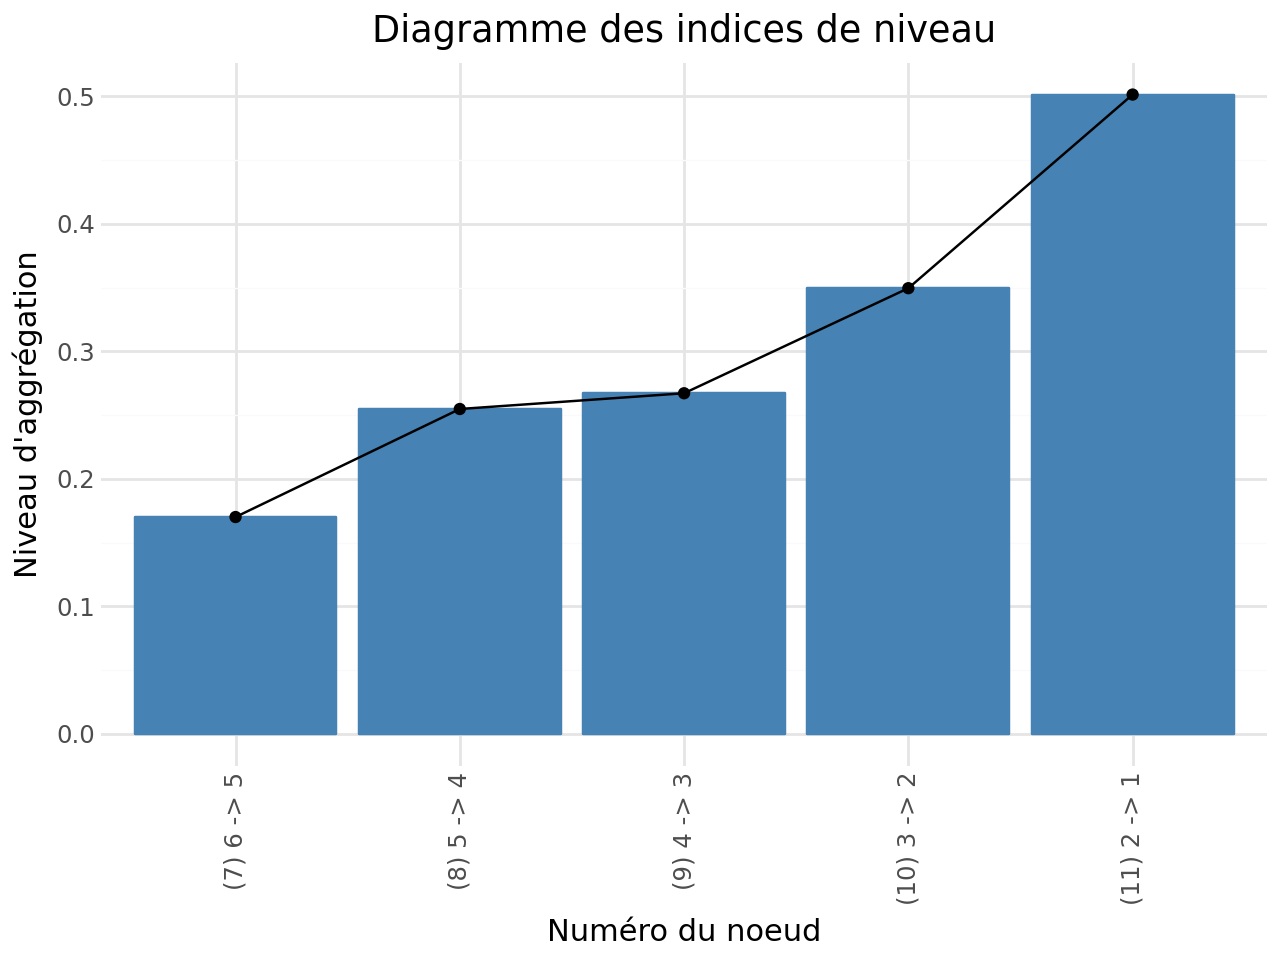

None


In [23]:
# graph of height
p = fviz_height(clf)
print(p.show())

## Supplementary variables informations

In [24]:
# supplementary variables informations
var_sup_ = clf.var_sup_
var_sup_._fields

('cluster', 'cor', 'cortest', 'sqload', 'member')

### Cluster

In [25]:
# cluster
var_sup_.cluster.to_frame()

,cluster
affiliation,2


### Squared loadings

In [26]:
# squared loadings - supplementary variables
var_sup_.sqload

,1,2
affiliation,0.513072,0.767037


### Cluster member

In [27]:
# cluster member
var_sup_.member.sort_values(by=["Cluster","Variable"])

,Variable,Cluster,Own Cluster,Next Closest,1 - R**2 Ratio
0,affiliation,2,0.767037,0.513072,0.478433


## Summary

In [28]:
# summary
from clustvartools import summary
summary(clf)

                     Clustering of Variables - CatCLV Results                     

Cluster Summary for 2 Clusters:
  Cluster  Members  Variation Explained  Proportion Explained
0       1        3             2.575215              0.429203
1       2        3             2.383310              0.397218

Inter-cluster Correlations:
          1         2
1  1.000000  0.795049
2  0.795049  1.000000

Cluster Squared Loadings:
                 1       2
budget      0.4992  0.7914
physician   0.5757  0.8285
salvador    0.8878  0.5920
nicaraguan  0.8601  0.5667
missile     0.8273  0.4805
education   0.4379  0.7635

Cluster Members and Squared Loadings values:
     Variable Cluster Own Cluster Next Closest 1 - R**2 Ratio
0      budget       2    0.791355     0.499226       0.416646
1   physician       2    0.828474     0.575691       0.404247
2    salvador       1    0.887756     0.591985       0.275098
3  nicaraguan       1    0.860118     0.566738       0.322857
4     missile       1    0.8273

In [29]:
# summary with detailed
summary(clf,detailed=True)

                     Clustering of Variables - CatCLV Results                     

Cluster Summary for 2 Clusters:
  Cluster  Members  Variation Explained  Proportion Explained
0       1        3             2.575215              0.429203
1       2        3             2.383310              0.397218

Inter-cluster Correlations:
          1         2
1  1.000000  0.795049
2  0.795049  1.000000

Linear coefficients:
                                          1             2
const                          3.330669e-16  5.551115e-16
budget_budget.n                         NaN -7.136051e-01
budget_budget.neither                   NaN  1.737009e-01
budget_budget.y                         NaN  4.747658e-01
physician_physician.n                   NaN  4.923318e-01
physician_physician.neither             NaN  3.950269e-01
physician_physician.y                   NaN -7.115890e-01
salvador_salvador.n            6.022180e-01           NaN
salvador_salvador.neither      2.816341e-02           NaN
s

In [30]:
# markdown formatting
summary(clf,to_markdown=True)

                     Clustering of Variables - CatCLV Results                     

Cluster Summary for 2 Clusters:
      Cluster    Members    Variation Explained    Proportion Explained
--  ---------  ---------  ---------------------  ----------------------
 0          1          3                2.57522                0.429203
 1          2          3                2.38331                0.397218

Inter-cluster Correlations:
           1         2
--  --------  --------
 1  1         0.795049
 2  0.795049  1

Cluster Squared Loadings:
                 1       2
----------  ------  ------
budget      0.4992  0.7914
physician   0.5757  0.8285
salvador    0.8878  0.592
nicaraguan  0.8601  0.5667
missile     0.8273  0.4805
education   0.4379  0.7635

Cluster Members and Squared Loadings values:
    Variable      Cluster    Own Cluster    Next Closest    1 - R**2 Ratio
--  ----------  ---------  -------------  --------------  ----------------
 0  budget              2       0.791355    

In [31]:
# markdown formatting
summary(clf,detailed=True,to_markdown=True)

                     Clustering of Variables - CatCLV Results                     

Cluster Summary for 2 Clusters:
      Cluster    Members    Variation Explained    Proportion Explained
--  ---------  ---------  ---------------------  ----------------------
 0          1          3                2.57522                0.429203
 1          2          3                2.38331                0.397218

Inter-cluster Correlations:
           1         2
--  --------  --------
 1  1         0.795049
 2  0.795049  1

Linear coefficients:
                                           1              2
-----------------------------  -------------  -------------
const                            3.33067e-16    5.55112e-16
budget_budget.n                nan             -0.713605
budget_budget.neither          nan              0.173701
budget_budget.y                nan              0.474766
physician_physician.n          nan              0.492332
physician_physician.neither    nan              0.39